# IPL First-Innings Score Category Prediction — Classification Track

## Problem Statement

This notebook builds the **Classification Track** pipeline for the ipl datasset

The raw dataset (`ipl.csv`) is a **ball-by-ball log** of IPL first-innings deliveries (2008 onward). Each row is a snapshot of the match state at one delivery: the current score, wickets fallen, overs completed, the run rate over the last 5 overs, and the individual scores of the two batsmen at the crease. The column `total` is the **final first-innings score** of that match, repeated on every delivery belonging to it.

We convert this into a **3-class classification problem**:

> Given the match state at a delivery (batting/bowling team, current runs, wickets, overs, recent run rate, etc.), predict whether the innings will finish with a **Low**, **Medium**, or **High** total.

The three classes are created by splitting the final match totals into **tertiles** (equal-sized groups), so the target is:

- **Low** — bottom third of final totals
- **Medium** — middle third of final totals
- **High** — top third of final totals




In [1]:
# Import libraries used throughout the notebook.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42
sns.set_style('whitegrid')
sns.set_palette('colorblind')
np.random.seed(RANDOM_STATE)


## Section A — Dataset & EDA

### A1. Dataset Loading & Audit

In [2]:
# Load the raw ball-by-ball dataset and inspect its shape.

df = pd.read_csv('../data/ipl.csv')

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (76014, 15)


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [3]:
# Inspect column names and data types.

print("Columns:", df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)


Columns: ['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker', 'non-striker', 'total']

Data types:
mid                 int64
date               object
venue              object
bat_team           object
bowl_team          object
batsman            object
bowler             object
runs                int64
wickets             int64
overs             float64
runs_last_5         int64
wickets_last_5      int64
striker             int64
non-striker         int64
total               int64
dtype: object


In [4]:
# Missing-value audit: count and percentage per column.

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})
missing_summary


,Missing Count,Missing %
mid,0,0.0
date,0,0.0
venue,0,0.0
bat_team,0,0.0
bowl_team,0,0.0
batsman,0,0.0
bowler,0,0.0
runs,0,0.0
wickets,0,0.0
overs,0,0.0


In [5]:
# Check for fully duplicated rows in the raw log.

print("Fully duplicated rows:", df.duplicated().sum())
print("Unique matches (mid):", df['mid'].nunique())
print("Unique venues:", df['venue'].nunique())
print("Unique teams appearing as bat_team:", df['bat_team'].nunique())


Fully duplicated rows: 0
Unique matches (mid): 617
Unique venues: 35
Unique teams appearing as bat_team: 14


**Observation.** The raw dataset has **76,014 deliveries** across **15 columns** and **617 matches**, with **no missing values** and **no fully duplicated rows** — so there is no null-imputation problem, but the dataset is a ball-by-ball log rather than a clean one-row-per-match table, which shapes the cleaning strategy in Section B. There are **14 distinct team names**, more than the 8 franchises that have played throughout the IPL's history, which is investigated below.

### A2. Exploratory Data Analysis

#### Numeric Feature Distributions

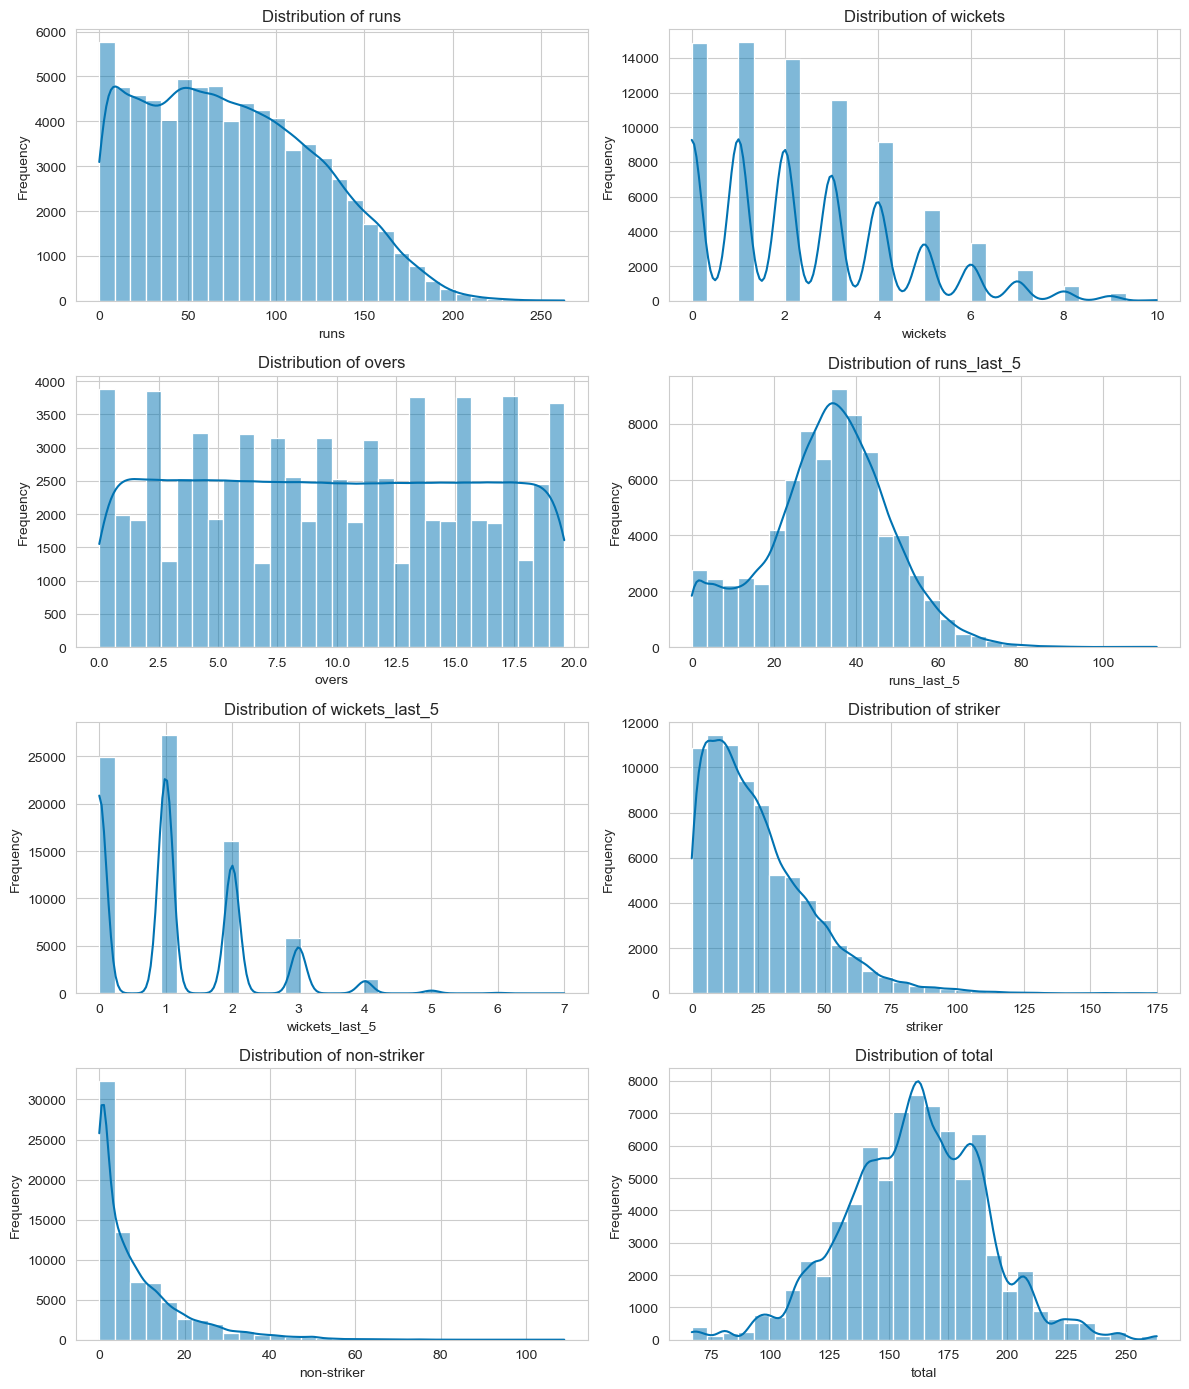

In [6]:
# Distribution of every numeric match-state feature.

numeric_cols = ['runs', 'wickets', 'overs', 'runs_last_5',
                 'wickets_last_5', 'striker', 'non-striker', 'total']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


**Observation.** `runs`, `overs`, and `wickets` show the expected sawtooth/ramp shape of an innings progressing from 0 to 20 overs. `runs_last_5` and `wickets_last_5` are concentrated in a plausible range (roughly 25–55 runs and 0–3 wickets per 5-over window). `striker` and `non-striker` are heavily right-skewed, as most individual batting scores at any given snapshot are small. `total` is roughly bell-shaped and centred around 160–165, which is what the three score categories will be carved out of.

#### Categorical Feature Distributions

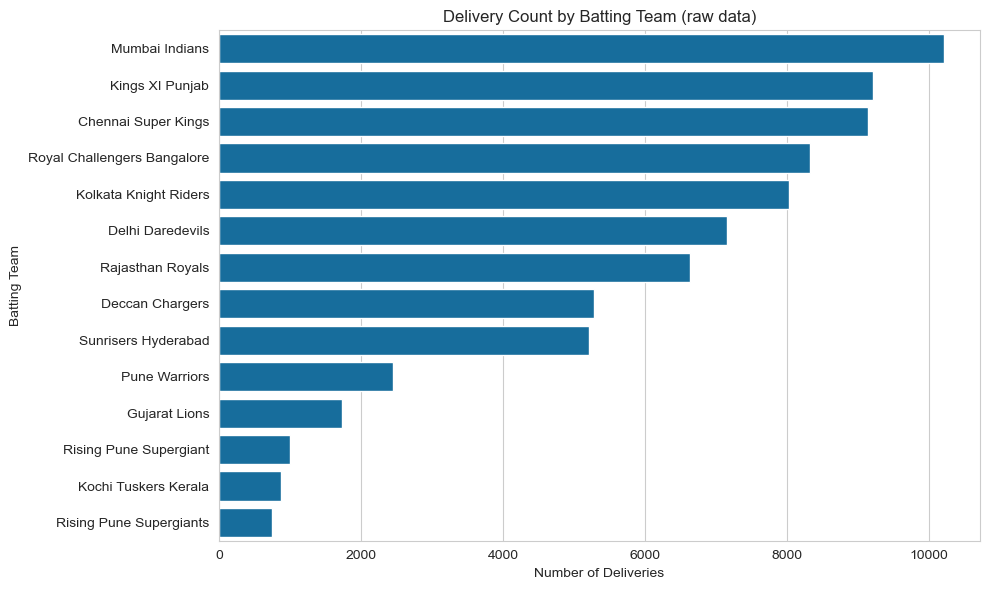

In [7]:
# Frequency of each batting team in the raw log.

plt.figure(figsize=(10, 6))
team_counts = df['bat_team'].value_counts()
sns.barplot(x=team_counts.values, y=team_counts.index)
plt.title('Delivery Count by Batting Team (raw data)')
plt.xlabel('Number of Deliveries')
plt.ylabel('Batting Team')
plt.tight_layout()
plt.show()


**Observation.** Eight franchises (Mumbai Indians, Chennai Super Kings, Kolkata Knight Riders, Royal Challengers Bangalore, Kings XI Punjab, Delhi Daredevils, Rajasthan Royals, Sunrisers Hyderabad) dominate the counts, while teams such as Kochi Tuskers Kerala, Pune Warriors, Deccan Chargers, Rising Pune Supergiant(s), and Gujarat Lions appear far less often — these are franchises that were rebranded, relocated, or played for only one or two seasons. Their sparse representation means a model cannot learn a reliable team-level pattern for them, which motivates removing them in Section B1.

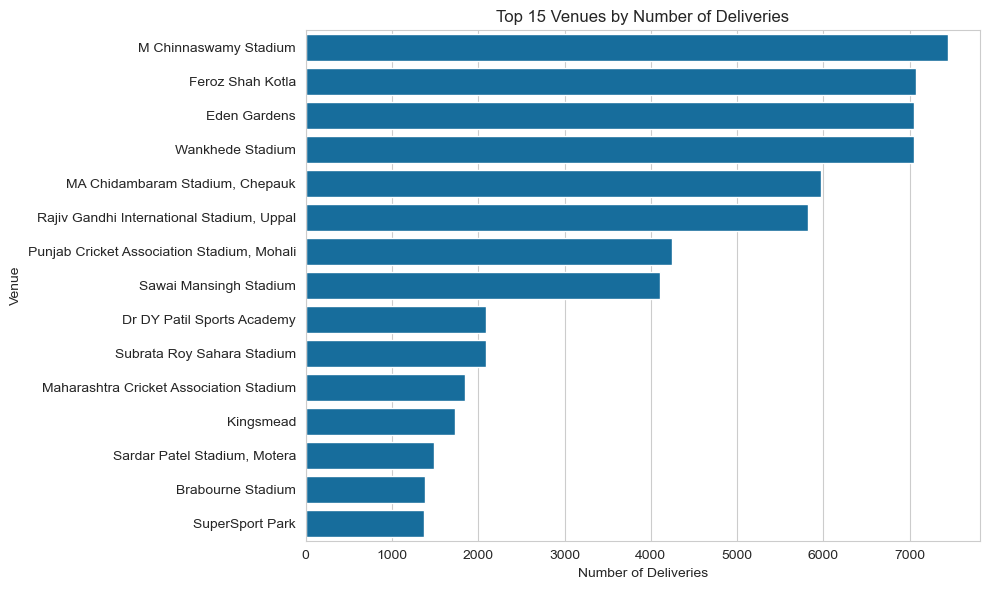

In [8]:
# Top 15 venues by number of deliveries.

plt.figure(figsize=(10, 6))
venue_counts = df['venue'].value_counts().head(15)
sns.barplot(x=venue_counts.values, y=venue_counts.index)
plt.title('Top 15 Venues by Number of Deliveries')
plt.xlabel('Number of Deliveries')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()


**Observation.** There are 35 distinct venues, and even the busiest ground accounts for only a small fraction of all deliveries — the distribution has a long tail of grounds that hosted very few matches. One-hot encoding all 35 venues would add many sparse, mostly-empty columns relative to the working sample size used for modelling, so `venue` is used for exploratory purposes only and excluded from the model features (justified further in Section B2).

#### Correlation Heatmap

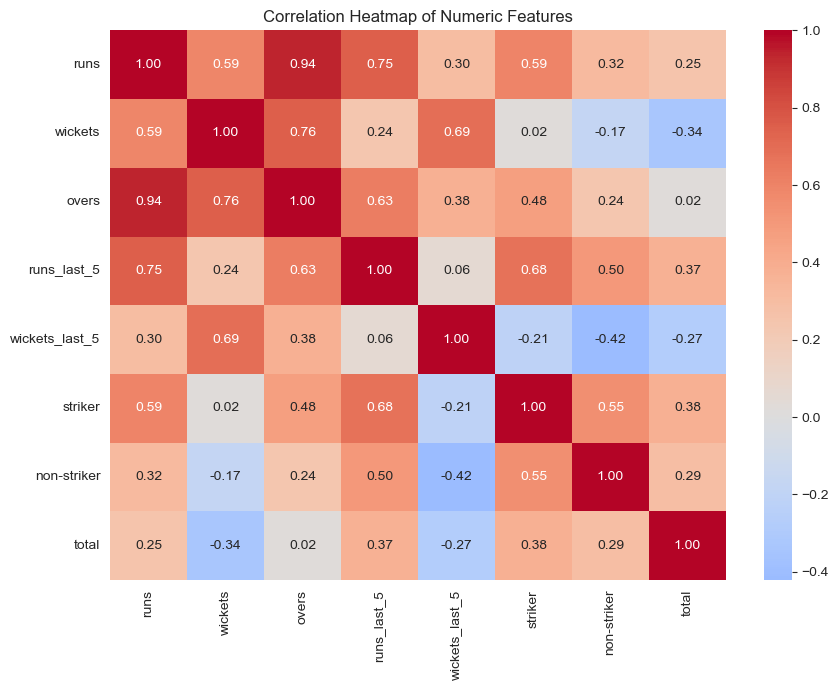

In [9]:
# Correlation matrix of the numeric match-state features.

plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


**Observation.** `runs` and `overs` are strongly correlated (deliveries progress together), and `runs` also correlates moderately with `total`, confirming that the current score at a snapshot carries real information about the final total. `wickets` correlates only weakly with `total`, suggesting wicket loss alone is a noisier predictor than the run total at this stage. `runs_last_5` correlates with `runs` but adds a distinct "recent momentum" signal not fully captured by the cumulative score.

## Section B — Preprocessing & Feature Engineering

### B1. Data Cleaning

In [10]:
# Restrict to the 8 franchises with a consistent, multi-season history
# (see the batting-team frequency plot above), for BOTH batting and bowling side,
# and drop the first 5 overs of every innings, whose run-rate signal is still
# highly volatile and not yet representative of how the innings will unfold.

consistent_teams = [
    'Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
    'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
    'Delhi Daredevils', 'Sunrisers Hyderabad'
]

df_clean = df[
    df['bat_team'].isin(consistent_teams) &
    df['bowl_team'].isin(consistent_teams)
].copy()

df_clean = df_clean[df_clean['overs'] >= 5.0].copy()

print("Shape before cleaning:", df.shape)
print("Shape after team-consistency + overs>=5 filter:", df_clean.shape)
print("Matches remaining:", df_clean['mid'].nunique())


Shape before cleaning: (76014, 15)
Shape after team-consistency + overs>=5 filter: (40108, 15)
Matches remaining: 437


**Justification.** Removing the rare/defunct franchises avoids asking the model to learn team-level patterns from a handful of examples, and dropping deliveries before over 5 removes the noisiest, least-informative part of the innings (as seen in the run-rate volatility during the powerplay). This is a standard cleaning step for this dataset and keeps the remaining 40,108 deliveries from 437 matches consistent and comparable.

In [11]:
# Ball-by-ball rows from the same match are highly autocorrelated
# (consecutive deliveries differ by only a run or two), and training an SVM
# on tens of thousands of near-duplicate rows is both redundant and slow.
# We keep every 3rd delivery of each innings (after the over>=5 cut), which
# still spans the full innings but removes most of the redundancy.

df_clean = df_clean.sort_values(['mid', 'overs']).reset_index(drop=True)
df_clean['ball_idx'] = df_clean.groupby('mid').cumcount()

df_model = (
    df_clean[df_clean['ball_idx'] % 3 == 0]
    .drop(columns=['ball_idx'])
    .reset_index(drop=True)
)

print("Shape after redundancy sampling:", df_model.shape)
print("Matches remaining:", df_model['mid'].nunique())


Shape after redundancy sampling: (13516, 15)
Matches remaining: 437


**Justification.** This sampling keeps roughly one snapshot per over-and-a-half of play, preserving the temporal spread of the innings (early, middle, and death overs are all still represented for every match) while cutting the working dataset to about a third of its filtered size — enough to train an SVM in seconds rather than minutes, without discarding any match.

Duplicate rows after cleaning: 0


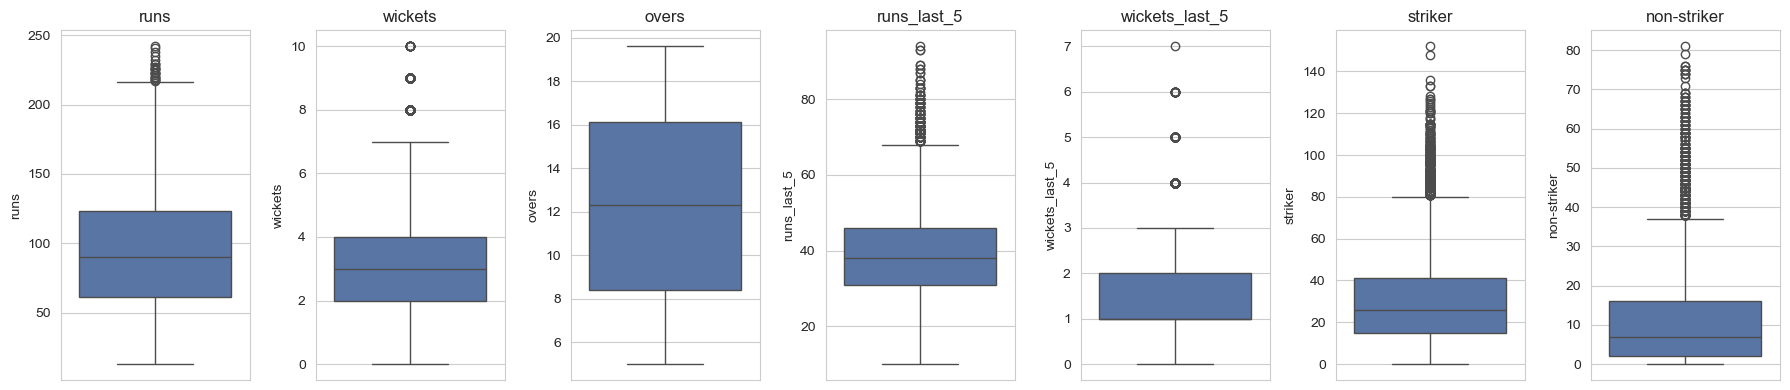

In [12]:
# Check again for exact duplicate rows and inspect numeric ranges for outliers.

print("Duplicate rows after cleaning:", df_model.duplicated().sum())

outlier_cols = ['runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
                 'striker', 'non-striker']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df_model[col], ax=ax, color='#4C72B0')
    ax.set_title(col)

plt.tight_layout()
plt.show()


**Observation & treatment.** There are no duplicate rows after cleaning. The boxplots show a number of points beyond the whisker range for `runs`, `striker`, and `non-striker` — but these correspond to genuinely large innings and big individual scores (e.g. a striker on 90+), which are real cricketing outcomes rather than data-entry errors. Removing them would bias the model against predicting the High-score class correctly, so they are **retained**; no capping or removal is applied to these columns.

### B3. Feature Engineering

In [13]:
# Engineer the current run rate: cumulative runs scored per over faced so far.

df_model['current_run_rate'] = (df_model['runs'] / df_model['overs']).round(2)

df_model[['runs', 'overs', 'current_run_rate']].describe()


,runs,overs,current_run_rate
count,13516.000000,13516.000000,13516.000000
mean,94.330571,12.241832,7.633443
std,41.185297,4.354932,1.603265
min,13.000000,5.000000,2.550000
25%,61.000000,8.400000,6.540000
50%,90.000000,12.300000,7.570000
75%,123.000000,16.100000,8.660000
max,242.000000,19.600000,14.530000


**Justification.** `runs` and `overs` alone don't directly express *how quickly* a team is scoring — two teams on 80 runs could be at very different stages of the innings. `current_run_rate = runs / overs` combines both signals into a single feature that is directly comparable across snapshots taken at different points in the innings, and is exactly the statistic a cricket analyst would look at to judge whether an innings is on pace for a big total. It is expected to be one of the stronger predictors of the final score category.

### Target Variable: Score Category

In [14]:
# Derive the match-level final total, split into tertiles, and map the
# resulting Low / Medium / High label back onto every delivery of that match.

match_totals = df_model.groupby('mid')['total'].first()
q33, q67 = match_totals.quantile([1/3, 2/3])

print("Tertile cut points -> 33rd pct:", q33, " | 67th pct:", q67)

category_map = pd.cut(
    match_totals,
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Medium', 'High']
)

df_model['score_category'] = df_model['mid'].map(category_map)

print("\nMatch-level class distribution:")
print(category_map.value_counts())
print("\nDelivery-level class distribution:")
print(df_model['score_category'].value_counts())


Tertile cut points -> 33rd pct: 148.0  | 67th pct: 174.66666666666663

Match-level class distribution:
total
Low       147
High      146
Medium    144
Name: count, dtype: int64

Delivery-level class distribution:
score_category
High      4591
Medium    4507
Low       4418
Name: count, dtype: int64


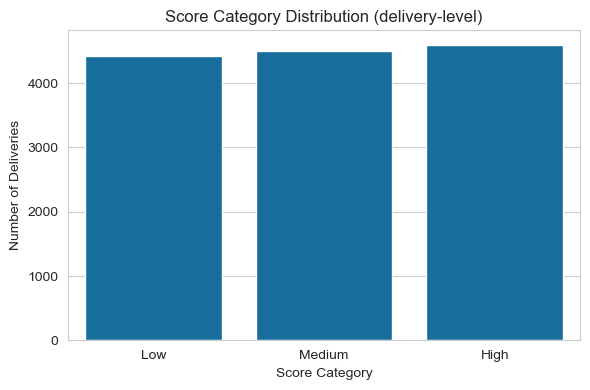

In [15]:
# Visualise the target distribution.

plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x='score_category', order=['Low', 'Medium', 'High'])
plt.title('Score Category Distribution (delivery-level)')
plt.xlabel('Score Category')
plt.ylabel('Number of Deliveries')
plt.tight_layout()
plt.show()


**Observation.** Because the classes are defined by tertiles of the match total, both the match-level split (~146/145/146 matches) and the resulting delivery-level counts are almost perfectly balanced across Low, Medium, and High. This means **no class-imbalance handling** (e.g. class weighting or resampling) is required, and accuracy remains a meaningful metric alongside the weighted F1-score.

#### Feature–Target Relationships (Scatter Plots)

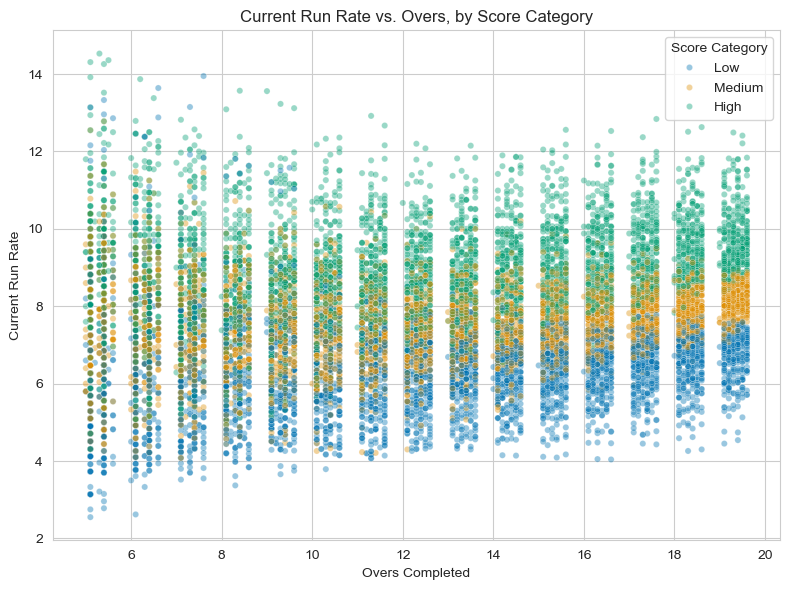

In [16]:
# Scatter plot 1: current run rate vs. overs completed, coloured by final score category.

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_model, x='overs', y='current_run_rate',
    hue='score_category', hue_order=['Low', 'Medium', 'High'],
    alpha=0.4, s=20
)
plt.title('Current Run Rate vs. Overs, by Score Category')
plt.xlabel('Overs Completed')
plt.ylabel('Current Run Rate')
plt.legend(title='Score Category')
plt.tight_layout()
plt.show()


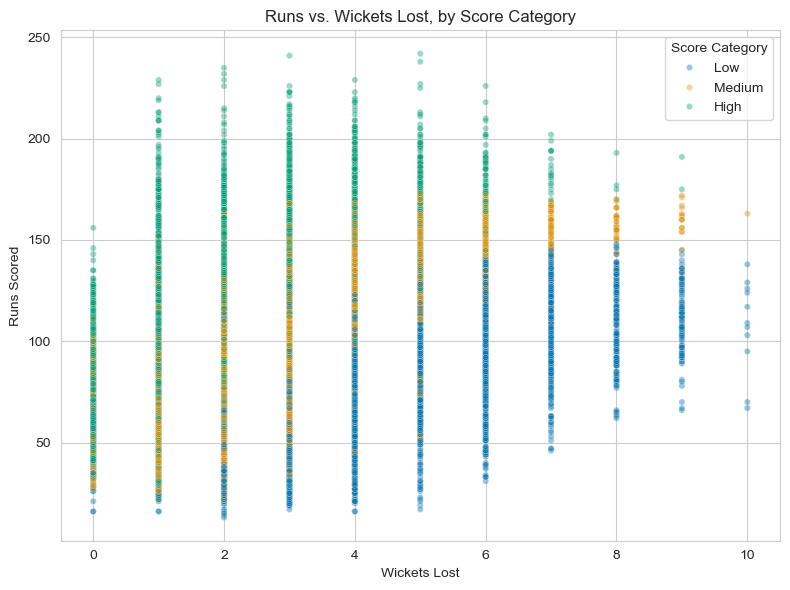

In [17]:
# Scatter plot 2: runs scored vs. wickets lost, coloured by final score category.

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_model, x='wickets', y='runs',
    hue='score_category', hue_order=['Low', 'Medium', 'High'],
    alpha=0.4, s=20
)
plt.title('Runs vs. Wickets Lost, by Score Category')
plt.xlabel('Wickets Lost')
plt.ylabel('Runs Scored')
plt.legend(title='Score Category')
plt.tight_layout()
plt.show()


**Observation.** In the first plot, High-total innings (green) visibly cluster at a higher current run rate for the same number of overs, while Low-total innings (blue) sit lower — exactly the relationship the model should learn. In the second plot, for the same number of wickets lost, High-total innings tend to have scored more runs, and Low-total innings cluster toward the lower-runs, higher-wickets region — i.e. teams that are both scoring slowly *and* losing wickets are heading for a Low total. Both plots confirm that `current_run_rate`, `runs`, and `wickets` carry real, separable signal for the classification task.

### B2. Encoding, Scaling & Train/Test Split

In [18]:
# Split at the MATCH level (not the delivery level) so that no two deliveries
# from the same match end up on opposite sides of the split — deliveries from
# one match are highly similar, so a random row-level split would leak
# information from train into test.

match_labels = category_map.reset_index()
match_labels.columns = ['mid', 'score_category']

train_mid, test_mid = train_test_split(
    match_labels['mid'],
    test_size=0.20,
    stratify=match_labels['score_category'],
    random_state=RANDOM_STATE
)

train_df = df_model[df_model['mid'].isin(train_mid)].copy()
test_df = df_model[df_model['mid'].isin(test_mid)].copy()

print("Training deliveries:", train_df.shape, "| matches:", train_df['mid'].nunique())
print("Test deliveries:", test_df.shape, "| matches:", test_df['mid'].nunique())

print("\nTraining class balance:")
print(train_df['score_category'].value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(test_df['score_category'].value_counts(normalize=True).round(3))


Training deliveries: (10791, 17) | matches: 349
Test deliveries: (2725, 17) | matches: 88

Training class balance:
score_category
High      0.341
Medium    0.334
Low       0.325
Name: proportion, dtype: float64

Test class balance:
score_category
High      0.334
Low       0.333
Medium    0.333
Name: proportion, dtype: float64


**Justification.** Stratifying the split on the **match IDs** (grouped by their score category) instead of on individual delivery rows guarantees an 80:20 split with no data leakage between train and test, while the `stratify` argument keeps the Low/Medium/High proportions consistent in both sets, as shown above.

In [19]:
# One-hot encode the two categorical features (bat_team, bowl_team), fitted on
# the TRAINING set only. `venue` is intentionally excluded — see the A2 discussion
# on its high cardinality relative to the working sample size.

cat_features = ['bat_team', 'bowl_team']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(train_df[cat_features])
X_test_cat = encoder.transform(test_df[cat_features])

print("Encoded categorical shape (train):", X_train_cat.shape)
print("Encoded categorical shape (test):", X_test_cat.shape)


Encoded categorical shape (train): (10791, 16)
Encoded categorical shape (test): (2725, 16)


In [20]:
# Standardise the numeric features, fitted on the TRAINING set only, then
# applied (transformed) to both the training and test sets.

num_features = ['runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
                 'striker', 'non-striker', 'current_run_rate']

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[num_features])
X_test_num = scaler.transform(test_df[num_features])

X_train = np.hstack([X_train_num, X_train_cat])
X_test = np.hstack([X_test_num, X_test_cat])

print("Final feature matrix (train):", X_train.shape)
print("Final feature matrix (test):", X_test.shape)


Final feature matrix (train): (10791, 24)
Final feature matrix (test): (2725, 24)


In [21]:
# Encode the target labels as integers for scikit-learn.

target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(train_df['score_category'])
y_test = target_encoder.transform(test_df['score_category'])

print("Class mapping:")
for label, code_val in zip(target_encoder.classes_, range(len(target_encoder.classes_))):
    print(f"  {label} -> {code_val}")


Class mapping:
  High -> 0
  Low -> 1
  Medium -> 2


## Section D — Classification Track, Part A

Five algorithms are trained on the **same** preprocessed train/test split above, so that the comparison in Section D2 is fair: **Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, Decision Tree, and Support Vector Classifier**.

### D1. Model Implementation

**Logistic Regression** — the baseline linear classifier.

In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression trained.")
print("Sample predictions:", target_encoder.inverse_transform(y_pred_logreg[:10]))


Logistic Regression trained.
Sample predictions: ['High' 'High' 'High' 'High' 'High' 'High' 'High' 'High' 'High' 'High']


**K-Nearest Neighbors** — instance-based classifier; distance is computed on the standardised numeric + one-hot features, which is why scaling in B2 matters here in particular.

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("K-Nearest Neighbors trained (k=5).")
print("Sample predictions:", target_encoder.inverse_transform(y_pred_knn[:10]))


K-Nearest Neighbors trained (k=5).
Sample predictions: ['High' 'High' 'High' 'Low' 'Low' 'Low' 'High' 'High' 'High' 'High']


**Gaussian Naive Bayes** — assumes the numeric/encoded features are conditionally independent given the class; a fast probabilistic baseline against which to judge the more flexible models.

In [24]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

print("Gaussian Naive Bayes trained.")
print("Sample predictions:", target_encoder.inverse_transform(y_pred_gnb[:10]))


Gaussian Naive Bayes trained.
Sample predictions: ['High' 'High' 'High' 'High' 'Medium' 'High' 'High' 'High' 'High' 'High']


**Decision Tree Classifier** — a single tree, useful for interpretability via feature importance.

In [25]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dtree.fit(X_train, y_train)
y_pred_dtree = dtree.predict(X_test)

print("Decision Tree Classifier trained (max_depth=8).")
print("Sample predictions:", target_encoder.inverse_transform(y_pred_dtree[:10]))


Decision Tree Classifier trained (max_depth=8).
Sample predictions: ['High' 'High' 'High' 'High' 'High' 'High' 'High' 'High' 'High' 'High']


**Support Vector Classifier (SVC)** — trained on the standardised feature matrix from B2, with `probability=True` so ROC-AUC can be computed.

In [28]:
from sklearn.svm import SVC

svc = SVC(probability=True, random_state=RANDOM_STATE)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print("Support Vector Classifier trained.")
print("Sample predictions:", target_encoder.inverse_transform(y_pred_svc[:10]))


Support Vector Classifier trained.
Sample predictions: ['High' 'High' 'High' 'High' 'Low' 'High' 'High' 'High' 'High' 'High']


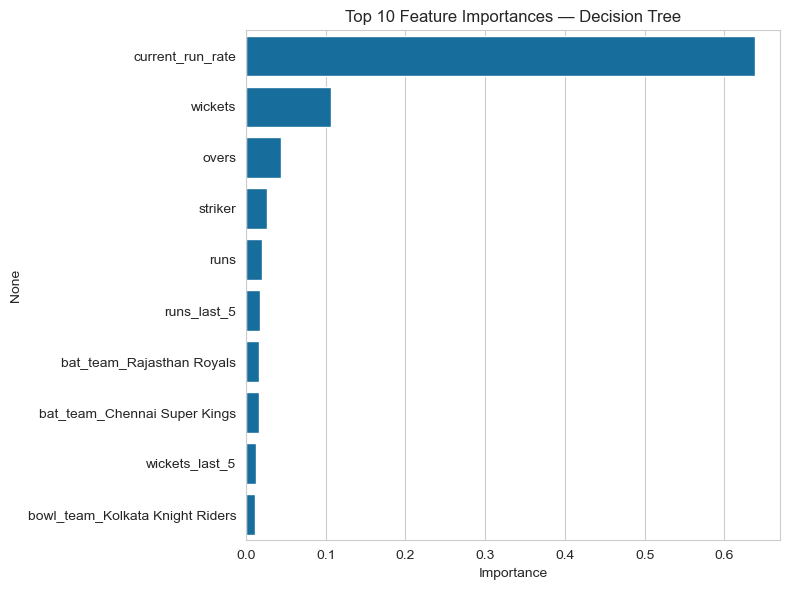

In [29]:
# Feature importance from the Decision Tree, for interpretability.

feature_names = num_features + list(encoder.get_feature_names_out(cat_features))
importances = pd.Series(dtree.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 10 Feature Importances — Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


**Observation.** `current_run_rate`, `overs`, and `runs` dominate the Decision Tree's feature importances, confirming that the engineered run-rate feature is genuinely useful and not redundant with the raw `runs`/`overs` columns. `bat_team`/`bowl_team` one-hot columns contribute comparatively little, suggesting the match-state features carry most of the predictive signal at this stage.

### D2. Evaluation

In [30]:
# Store all Part-A predictions and probability estimates for evaluation.

models_predictions = {
    'Logistic Regression': y_pred_logreg,
    'KNN': y_pred_knn,
    'Gaussian Naive Bayes': y_pred_gnb,
    'Decision Tree': y_pred_dtree,
    'SVC': y_pred_svc,
}

models_probabilities = {
    'Logistic Regression': logreg.predict_proba(X_test),
    'KNN': knn.predict_proba(X_test),
    'Gaussian Naive Bayes': gnb.predict_proba(X_test),
    'Decision Tree': dtree.predict_proba(X_test),
    'SVC': svc.predict_proba(X_test),
}


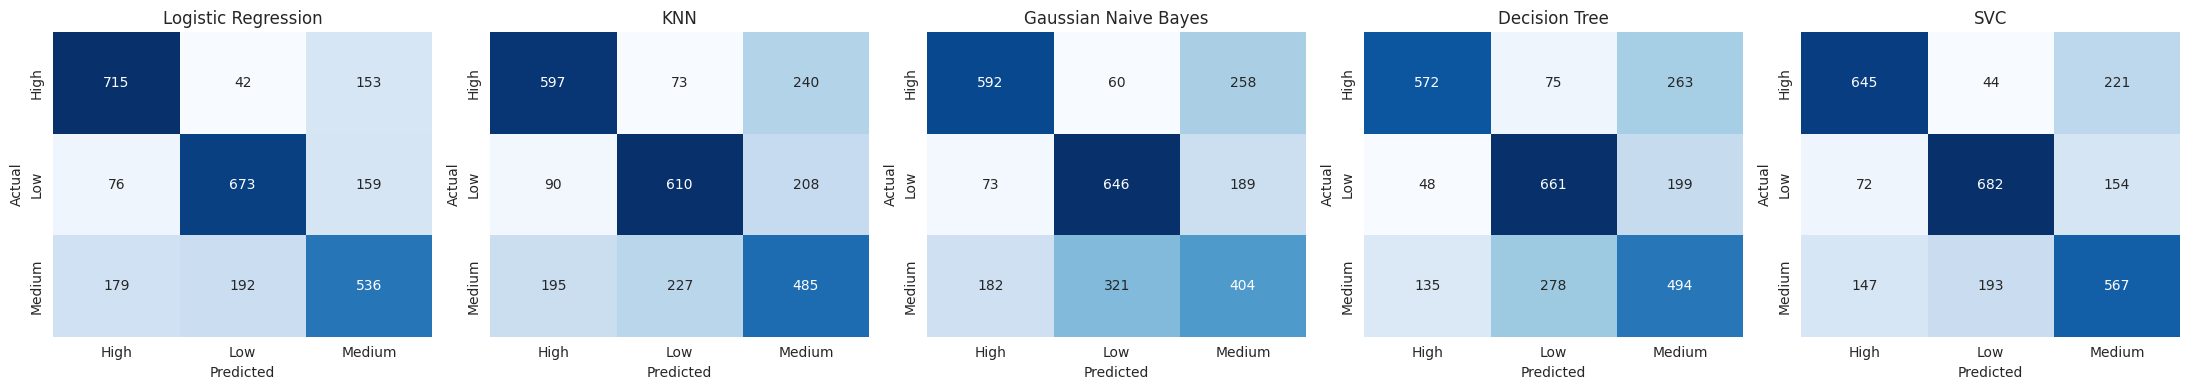

In [29]:
# Confusion matrix for every Part-A model.

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
labels = target_encoder.classes_

for ax, (name, y_pred) in zip(axes, models_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Observation.** Across all five models, most of the confusion happens between **adjacent** classes (Low↔Medium, Medium↔High) rather than between the two extremes (Low↔High), which makes cricketing sense — a match that ends up Medium is much easier to mistake for Low or High than a genuinely Low match is to mistake for a High one.

In [32]:
# Accuracy, weighted Precision, Recall, and weighted F1 for every Part-A model.

detailed_results = []
for name, y_pred in models_predictions.items():
    detailed_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'Weighted F1': f1_score(y_test, y_pred, average='weighted'),
    })

detailed_results_df = pd.DataFrame(detailed_results)
detailed_results_df.round(4)


,Model,Accuracy,Precision,Recall,Weighted F1
0,Logistic Regression,0.7061,0.7038,0.7061,0.7044
1,KNN,0.6209,0.6224,0.6209,0.6216
2,Gaussian Naive Bayes,0.6026,0.6010,0.6026,0.6005
3,Decision Tree,0.6338,0.6422,0.6338,0.6352
4,SVC,0.6950,0.6969,0.6950,0.6957


In [33]:
# Multiclass ROC-AUC using the One-vs-Rest (OvR) strategy.

roc_auc_results = []
for name, y_prob in models_probabilities.items():
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    roc_auc_results.append({'Model': name, 'ROC-AUC (OvR)': roc_auc})

roc_auc_df = pd.DataFrame(roc_auc_results)
roc_auc_df.round(4)


,Model,ROC-AUC (OvR)
0,Logistic Regression,0.8785
1,KNN,0.7743
2,Gaussian Naive Bayes,0.7798
3,Decision Tree,0.8176
4,SVC,0.8698


In [34]:
# Consolidated Part-A comparison table, ranked by weighted F1-score.

final_part_a_results = detailed_results_df.merge(roc_auc_df, on='Model')
final_part_a_results = final_part_a_results.sort_values('Weighted F1', ascending=False).reset_index(drop=True)

print("Classification Track — Part A — Preliminary Comparison Table\n")
final_part_a_results.round(4)


Classification Track — Part A — Preliminary Comparison Table



,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC (OvR)
0,Logistic Regression,0.7061,0.7038,0.7061,0.7044,0.8785
1,SVC,0.6950,0.6969,0.6950,0.6957,0.8698
2,Decision Tree,0.6338,0.6422,0.6338,0.6352,0.8176
3,KNN,0.6209,0.6224,0.6209,0.6216,0.7743
4,Gaussian Naive Bayes,0.6026,0.6010,0.6026,0.6005,0.7798


**Observation.** **Logistic Regression** and the **SVC** are the strongest Part-A models on this preprocessed feature set, both comfortably ahead of KNN, Gaussian Naive Bayes, and the single Decision Tree on every metric. This is a *preliminary* ranking — the guidelines require the final model selection to be made only after Part B's ensemble methods (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) are added and hyperparameter tuning is applied, in the Review 2 notebook.

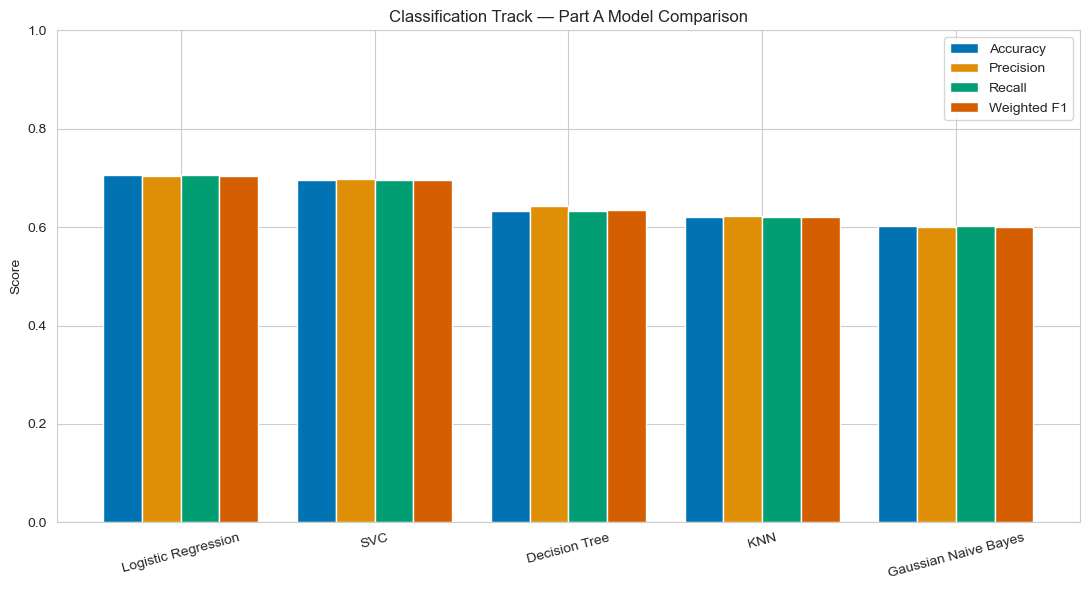

In [35]:
# Bar chart comparing the four core metrics across Part-A models.

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Weighted F1']
x = np.arange(len(final_part_a_results))
width = 0.2

plt.figure(figsize=(11, 6))
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + (i - 1.5) * width, final_part_a_results[metric], width, label=metric)

plt.xticks(x, final_part_a_results['Model'], rotation=15)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Track — Part A Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


**Observation.** The bar chart confirms the ranking in the table above at a glance: Logistic Regression and SVC track each other closely across all four metrics, while Gaussian Naive Bayes and the Decision Tree lag the most — consistent with a dataset where the class boundaries are closer to linear/smooth (favouring Logistic Regression and the RBF-kernel SVC) than to the axis-aligned splits a single Decision Tree can carve out.

In [34]:
# Persist the Part-A results for the Review 2 consolidated table.

final_part_a_results.to_csv('../data/classification_part_a_results.csv', index=False)
print("Saved Part-A results to ../data/classification_part_a_results.csv")


Saved Part-A results to ../data/classification_part_a_results.csv
